In [1]:
import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd
from pathlib import Path
import muon as mu
import scvi

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/")

reference_dir = PROJECT_DIR / "data" / "cell_label_reference_datasets"

# Start from the RNA modality
mouse_multiome_file = Path(
    PROJECT_DIR / "data/processed/mouse_liver/multiome_processed.h5mu"
)

# Read the multiome data and select the RNA adata modality
mouse_multiome = mu.read_h5mu(mouse_multiome_file)
rna = mouse_multiome.mod["rna"]

2026-09-08 16:47:53.568871: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_com

In [2]:
# Liver Cell Atlas, "Digest protocols / Nuclei" (Guilliams et al., Cell 2022).
#
# This is a single-NUCLEUS reference. The Tabula sets are whole-cell and cannot be used
# here: 10x Multiome needs intact nuclei, so it measures the nuclear compartment, while
# whole-cell hepatocyte identity rests on cytoplasmic mRNA (Alb, Apoa1, Ttr, Serpina1a)
# that a nucleus does not hold. Against the whole-cell reference that gap was 2.1-2.9 log
# units per marker and the transfer collapsed; against this one it is under 0.6.
lca_dir = reference_dir / "liver_cell_atlas"
lca_h5ad = lca_dir / "digestNuclei_annotated.h5ad"

if lca_h5ad.exists():
    tissue_ref_data = sc.read_h5ad(lca_h5ad)
else:
    # Reading the 27.5M-entry mtx takes a few minutes, so cache the result as h5ad.
    import gzip
    from scipy.io import mmread
    from scipy.sparse import csr_matrix

    mtx_dir = lca_dir / "rawData_digestNuclei" / "countTable_digestNuclei"
    features = [l.strip() for l in gzip.open(mtx_dir / "features.tsv.gz", "rt")]
    barcodes = [l.strip() for l in gzip.open(mtx_dir / "barcodes.tsv.gz", "rt")]

    # The matrix carries all 13372 barcodes; the annotation covers the 8583 QC-passed
    # cells used in the published UMAP. Keep those, in annotation order.
    annot = pd.read_csv(lca_dir / "annot_digestNuclei.csv")
    pos = {b: i for i, b in enumerate(barcodes)}
    annot = annot[annot["cell"].isin(pos)].copy()
    assert len(annot) == 8583, f"expected 8583 annotated cells, got {len(annot)}"

    M = mmread(mtx_dir / "matrix.mtx.gz").tocsc()                      # genes x cells
    M = csr_matrix(M[:, annot["cell"].map(pos).to_numpy()].T)          # cells x genes

    tissue_ref_data = ad.AnnData(
        X=M.astype(np.float32),
        obs=annot.set_index("cell"),
        var=pd.DataFrame(index=pd.Index(features, name=None)),
    )
    tissue_ref_data.write_h5ad(lca_h5ad)

# `annot` is the published label; `sample` is one of three mice (ABU7/ABU17/ABU20),
# which the barcode suffixes -1/-2/-3 map to one-to-one.
tissue_ref_data.obs["cell_type_ref"] = tissue_ref_data.obs["annot"].astype("category")
tissue_ref_data.obs["donor"] = "ref_" + tissue_ref_data.obs["sample"].astype(str)

# SCANVI cannot learn a class that has almost no cells in the reference
class_counts = tissue_ref_data.obs["cell_type_ref"].value_counts()
keep_classes = class_counts[class_counts >= 10].index
tissue_ref_data = tissue_ref_data[
    tissue_ref_data.obs["cell_type_ref"].isin(keep_classes)
].copy()
tissue_ref_data.obs["cell_type_ref"] = (
    tissue_ref_data.obs["cell_type_ref"].cat.remove_unused_categories()
)

# NOTE: stellate cells sit under "Fibroblasts" here (Dcn+, Lrat+). The separate "HpSC"
# label is not stellate -- it carries no Lrat and almost no Dcn.
print(tissue_ref_data.shape)
print(tissue_ref_data.obs["cell_type_ref"].value_counts())

(8583, 31053)
cell_type_ref
Hepatocytes       5547
Endothelial       1157
Fibroblasts        892
KCs                480
B cells            164
Cholangiocytes     113
HpSC                99
T cells             97
DCs                 34
Name: count, dtype: int64


In [3]:
# Extract the counts layer
obj = rna.copy()
obj.X = obj.layers["counts"].copy()

# Give scVI one batch level per 10x sample. The sample index is the barcode suffix.
obj.obs["donor"] = "query_" + obj.obs_names.str.rsplit("-", n=1).str[1]

print(obj.obs["donor"].value_counts())

donor
query_1    4098
query_4    3773
query_6    3067
query_3    2989
query_5    2973
query_7    2762
Name: count, dtype: int64


In [4]:
adata = obj.concatenate(tissue_ref_data)

# Preserve raw counts before normalization/log transformation
adata.layers["counts"] = adata.X.copy()

# Both halves of the object must hold integer counts. If this fails, one of the two
# inputs is normalized and every model below it will be meaningless. Check each
# batch separately: the query cells come first, so a head slice would miss the
# reference entirely.
for _batch in adata.obs["batch"].cat.categories:
    _sub = adata[adata.obs["batch"] == _batch].layers["counts"]
    _vals = _sub.data if hasattr(_sub, "data") else _sub
    assert np.allclose(_vals, np.round(_vals)), f"batch {_batch} counts are not integer"

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Store log-normalized expression in .raw
adata.raw = adata

# Find HVGs using the raw count layer. Batch here is query vs reference: the
# per-donor levels are too small for the seurat_v3 variance fit.
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=2000,
    layer="counts",
    batch_key="batch",
    subset=True
)

/tmp/ipykernel_2804832/2358998672.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = obj.concatenate(tissue_ref_data)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [5]:
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="donor")

In [6]:
model = scvi.model.SCVI(adata)
model.train(max_epochs=100, early_stopping=True)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/Home/esm5360/miniconda3

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [7]:
adata.obs['cell_type_ref'] = adata.obs['cell_type_ref'].cat.add_categories('Unknown')
adata.obs = adata.obs.fillna(value = {'cell_type_ref': 'Unknown'})

# Only the query cells should be unlabelled
n_unlabelled = (adata.obs['cell_type_ref'] == 'Unknown').sum()
assert n_unlabelled == (adata.obs['batch'] == '0').sum(), "unexpected unlabelled cells"
print(f"{n_unlabelled} query cells to label, {len(adata) - n_unlabelled} reference cells")

19662 query cells to label, 8583 reference cells


In [8]:
lvae = scvi.model.SCANVI.from_scvi_model(
    model, 
    adata=adata, 
    unlabeled_category='Unknown', 
    labels_key='cell_type_ref'
    )


In [9]:
lvae.train(max_epochs=20, n_samples_per_label=100)

INFO     Training for 20 epochs.                                                                                   


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/Home/esm5360/miniconda3

Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [10]:
adata.obs['predicted_cell_type'] = lvae.predict(adata)
adata.obs

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,leiden_joint,cell_type,donor,UMAP_1,UMAP_2,cluster,sample,annot,digest,typeSample,cell_type_ref,batch,_scvi_batch,_scvi_labels,predicted_cell_type
AAACAGCCAACACCTA-6-0,1230.0,1994.0,1.0,0.050150,0,0,endothelial cell of hepatic sinusoid,query_6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,4,9,Endothelial
AAACAGCCAACCCTAA-6-0,4153.0,13800.0,38.0,0.275362,2,2,Kupffer cell,query_6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,4,9,B cells
AAACAGCCAAGCTTTG-6-0,5990.0,28479.0,28.0,0.098318,4,5,hepatocyte,query_6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,4,9,Hepatocytes
AAACAGCCAATCTCTC-4-0,3649.0,11347.0,6.0,0.052877,6,7,B cell,query_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,2,9,T cells
AAACAGCCACTCAACA-4-0,6338.0,34997.0,17.0,0.048576,7,10,B cell,query_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,2,9,Hepatocytes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTCATGTGACT-3-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ref_ABU20,0.102073,12.362924,3.0,ABU20,Hepatocytes,nuclei,nucSeq,Hepatocytes,1,7,5,Hepatocytes
TTTGGTTGTCGCTTGG-3-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ref_ABU20,-0.396965,11.745289,3.0,ABU20,Hepatocytes,nuclei,nucSeq,Hepatocytes,1,7,5,Hepatocytes
TTTGTTGCAAAGTGTA-3-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ref_ABU20,7.959698,5.500991,4.0,ABU20,Fibroblasts,nuclei,nucSeq,Fibroblasts,1,7,4,Fibroblasts
TTTGTTGCACTGGACC-3-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ref_ABU20,4.906233,7.076482,17.0,ABU20,Fibroblasts,nuclei,nucSeq,Fibroblasts,1,7,4,Fibroblasts


In [11]:
# Keep only the query half. `concatenate` labels the first object batch "0".
query_obs = adata.obs[adata.obs["batch"] == "0"]

# `concatenate` appended a "-0" suffix. Strip it to recover the original barcodes.
barcodes = query_obs.index.str.rsplit("-", n=1).str[0]

# Make a barcode to cell type dictionary
cell_mapper = dict(zip(barcodes, query_obs["predicted_cell_type"]))

# Every query cell must appear exactly once, or barcodes collided
assert len(cell_mapper) == mouse_multiome.mod["rna"].n_obs, "barcodes are not unique"

In [12]:
# Map the predicted cell types back to the original multiome object
mouse_multiome.mod['rna'].obs['cell_type'] = mouse_multiome.mod['rna'].obs.index.map(lambda x: cell_mapper.get(x, 'Unknown'))

n_unknown = (mouse_multiome.mod['rna'].obs['cell_type'] == 'Unknown').sum()
print(f"{n_unknown} of {mouse_multiome.mod['rna'].n_obs} cells did not get a label")
print(mouse_multiome.mod['rna'].obs['cell_type'].value_counts())

0 of 19662 cells did not get a label
cell_type
Hepatocytes       6522
KCs               2637
T cells           2329
B cells           2070
Endothelial       1930
HpSC              1575
Cholangiocytes    1423
Fibroblasts       1097
DCs                 79
Name: count, dtype: int64


In [13]:
mouse_multiome.mod['rna'].obs

,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,leiden_joint,cell_type
AAACAGCCAACACCTA-6,1230,1994.0,1.0,0.050150,0,0,Endothelial
AAACAGCCAACCCTAA-6,4153,13800.0,38.0,0.275362,2,2,B cells
AAACAGCCAAGCTTTG-6,5990,28479.0,28.0,0.098318,4,5,Hepatocytes
AAACAGCCAATCTCTC-4,3649,11347.0,6.0,0.052877,6,7,T cells
AAACAGCCACTCAACA-4,6338,34997.0,17.0,0.048576,7,10,Hepatocytes
...,...,...,...,...,...,...,...
TTTGTTGGTTACGCAA-3,3731,12211.0,5.0,0.040947,11,7,T cells
TTTGTTGGTTATCCTA-7,2679,6153.0,10.0,0.162522,21,15,B cells
TTTGTTGGTTCATCTA-4,5158,20360.0,15.0,0.073674,7,10,Hepatocytes
TTTGTTGGTTTATGGG-7,1796,3094.0,14.0,0.452489,12,12,Hepatocytes


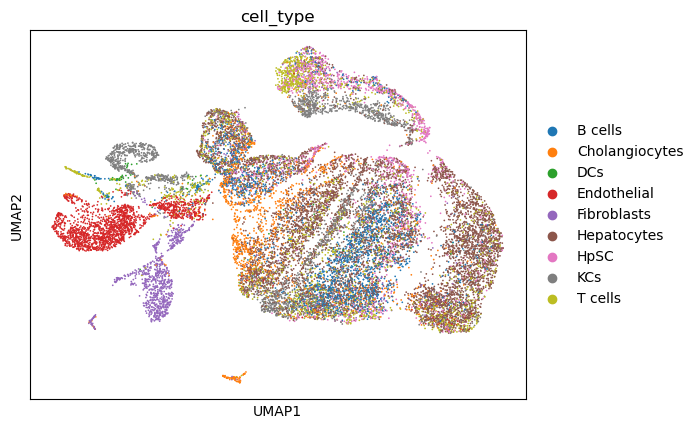

In [14]:
# Plot umap of the predicted cell types
sc.pl.umap(mouse_multiome.mod['rna'], color='cell_type')

In [27]:
marker_genes = pd.read_csv("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/all_cell_markers.txt", sep="\t", index_col=None, header=0)
marker_genes = marker_genes[marker_genes["cellType"] == "Normal cell"]
mouse_marker_genes = marker_genes[marker_genes['speciesType'] == "Mouse"]
mouse_liver_marker_genes = mouse_marker_genes[mouse_marker_genes['tissueType'] == "Liver"]
mouse_liver_marker_genes = mouse_liver_marker_genes.groupby("cellName").agg({"geneSymbol": lambda x: ", ".join(x)}).reset_index()
mouse_liver_marker_genes

,cellName,geneSymbol
0,B cell,Cd22
1,CD4+ T cell,"Cd44, Ptprc, Sell"
2,Cytotoxic T cell,Cd8a
3,Dendritic cell,"Itgax, Cd80, Cd83"
4,Endothelial cell,"Fcgr2b, Lyve1, Bmp2, C1qtnf1, Dpp4, F8, Il1a, ..."
5,Hepatoblast,"Afp, Afp"
6,Hepatocyte,"Afp, Albumin family, Afp, NA, Acly, Alb, Apoa1..."
7,Ito cell (hepatic stellate cell),"Syp, Stx2, Acta2, Des, Acta2, Igfbp3, Des, Gfap"
8,Kupffer cell,"Cd68, Clec4f, Adgre1, Clec4f, Irf7, Spic"
9,Liver progenitor cell,"Ascl2, Krt19, Dlk1, Epcam"


In [30]:
hepatocyte_marker_genes = mouse_liver_marker_genes[mouse_liver_marker_genes['cellName'] == 'Hepatocyte']['geneSymbol'].values[0]
print(f"Hepatocyte marker genes: {hepatocyte_marker_genes}")

Hepatocyte marker genes: Afp, Albumin family, Afp, NA, Acly, Alb, Apoa1, Asl, Ass1, Cyp2e1, Cyp2f2, G6pc, Glul, Mup3, Pck1


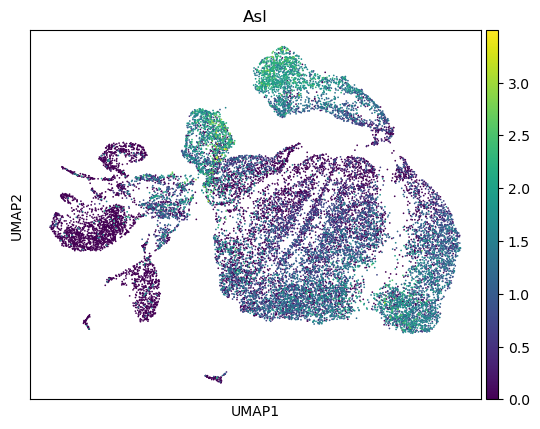

In [37]:
sc.pl.umap(mouse_multiome.mod['rna'], color='Asl')

In [16]:
# Write the labels back. This overwrites multiome_processed.h5mu in place, so any
# pseudobulk file built from the old version becomes stale.
mouse_multiome.mod["rna"].obs["cell_type"] = mouse_multiome.mod["rna"].obs["cell_type"].astype("category")
mu.write_h5mu(mouse_multiome_file, mouse_multiome)
print(f"wrote {mouse_multiome_file}")

wrote /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/multiome_processed.h5mu


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
